In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import glob
import math
import os
from tqdm import tqdm
import random

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from tqdm import tqdm
import random
import math
import glob
import os

# Define a range of thresholds from the minimum to the maximum score
def calculate_thresholds(genuine_scores, impostor_scores, num_thresholds=100):
    min_score = min(min(genuine_scores), min(impostor_scores))
    max_score = max(max(genuine_scores), max(impostor_scores))
    return np.linspace(min_score, max_score, num_thresholds)

# Compute FAR, FRR, and EER with Bootstrapping
def calculate_far_frr(threshold, genuine_scores, impostor_scores):
    far = np.sum(np.array(impostor_scores) >= threshold) / len(impostor_scores)
    frr = np.sum(np.array(genuine_scores) < threshold) / len(genuine_scores)
    return far, frr

def bootstrap_eer(thresholds, genuine_scores, impostor_scores, n_bootstrap=1000):
    far_values = []
    frr_values = []
    auc_values = []

    for _ in tqdm(range(n_bootstrap), desc="Bootstrapping Progress"):
        genuine_sample = [random.choice(genuine_scores) for _ in range(len(genuine_scores))]
        impostor_sample = [random.choice(impostor_scores) for _ in range(len(impostor_scores))]

        fars = []
        frrs = []
        for threshold in thresholds:
            far, frr = calculate_far_frr(threshold, genuine_sample, impostor_sample)
            fars.append(far)
            frrs.append(frr)

        roc_auc = auc(fars, 1 - np.array(frrs))
        auc_values.append(roc_auc)

        far_values.append(fars)
        frr_values.append(frrs)

    far_values = np.array(far_values)
    frr_values = np.array(frr_values)
    auc_values = np.array(auc_values)

    return far_values, frr_values, auc_values

# Plot single ROC curve with uncertainty
def plot_single_roc_with_uncertainty(csv_files,title, n_bootstrap=1000):
    plt.figure(figsize=(7, 5))

    # Separate files by technique
    mask_ddpg_files = [file for file in csv_files if 'MaskDDPG' in file[0]]
    cpp_deid_files = [file for file in csv_files if 'cpp-deid' in file[0]]

    # Define colors for each technique
    colors_mask_ddpg = plt.cm.plasma(np.linspace(0, 1, len(mask_ddpg_files)))
    colors_cpp_deid = plt.cm.cividis(np.linspace(0, 1, len(cpp_deid_files)))

    # Plot Mask-DDPG curves
    for idx, (path, label) in enumerate(mask_ddpg_files):
        data = pd.read_csv(path)
        genuine_scores = data[data['ground_truth'] == 1]['cossim'].tolist()
        impostor_scores = data[data['ground_truth'] == 0]['cossim'].tolist()

        thresholds = calculate_thresholds(genuine_scores, impostor_scores)
        far_values, frr_values, auc_values = bootstrap_eer(thresholds, genuine_scores, impostor_scores, n_bootstrap)

        mean_far = np.mean(far_values, axis=0)
        mean_frr = np.mean(frr_values, axis=0)

        far_std = np.std(far_values, axis=0)
        frr_std = np.std(frr_values, axis=0)

        roc_auc = np.mean(auc_values)
        auc_uncertainty = np.std(auc_values)

        plt.plot(mean_far, 1 - mean_frr, color=colors_mask_ddpg[idx], lw=1.5,
                 label=f'{label}; AUC={roc_auc:.2f} ± {auc_uncertainty:.6f}')
        plt.fill_between(mean_far, 1 - mean_frr - frr_std, 1 - mean_frr + frr_std, alpha=0.2, color=colors_mask_ddpg[idx])

    # Plot CPP-DeID curves
    for idx, (path, label) in enumerate(cpp_deid_files):
        data = pd.read_csv(path)
        genuine_scores = data[data['ground_truth'] == 1]['cossim'].tolist()
        impostor_scores = data[data['ground_truth'] == 0]['cossim'].tolist()

        thresholds = calculate_thresholds(genuine_scores, impostor_scores)
        far_values, frr_values, auc_values = bootstrap_eer(thresholds, genuine_scores, impostor_scores, n_bootstrap)

        mean_far = np.mean(far_values, axis=0)
        mean_frr = np.mean(frr_values, axis=0)

        far_std = np.std(far_values, axis=0)
        frr_std = np.std(frr_values, axis=0)

        roc_auc = np.mean(auc_values)
        auc_uncertainty = np.std(auc_values)

        plt.plot(mean_far, 1 - mean_frr, color=colors_cpp_deid[idx], lw=1.5,
                 label=f'{label}; AUC={roc_auc:.2f} ± {auc_uncertainty:.6f}')
        plt.fill_between(mean_far, 1 - mean_frr - frr_std, 1 - mean_frr + frr_std, alpha=0.2, color=colors_cpp_deid[idx])

    # Plot diagonal line
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey', lw=1)

    # Customize plot
    plt.xlabel('False acceptance rate (FAR)')
    plt.ylabel('Verification rate (VER)')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 73.23it/s]


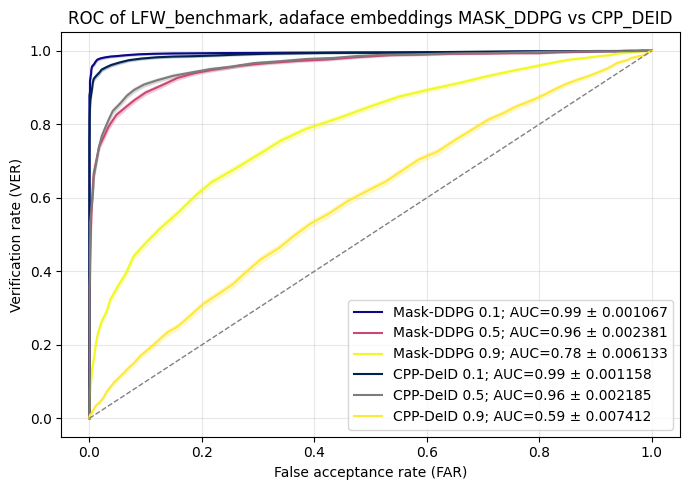

In [13]:
# Set the directory path for your CSV files
csv_files = [#pairs: path, label
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.1_MaskDDPG.csv','Mask-DDPG 0.1'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.9_cpp-deid.csv','CPP-DeID 0.1'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.5_MaskDDPG.csv','Mask-DDPG 0.5'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.5_cpp-deid.csv','CPP-DeID 0.5'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.9_MaskDDPG.csv','Mask-DDPG 0.9'),
    ('verification_results/adaface_LFW_benchmark_CPP_DEID/adaface_optimized_LFW_benchmark_0.1_cpp-deid.csv','CPP-DeID 0.9')
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, adaface embeddings MASK_DDPG vs CPP_DEID', n_bootstrap=1000)


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 73.74it/s]


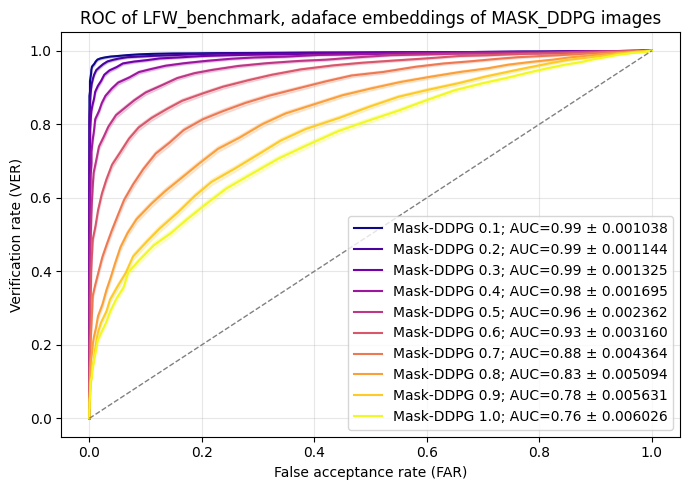

In [15]:
# Set the directory path for your CSV files
csv_files = [#pairs: path, label
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.1_MaskDDPG.csv','Mask-DDPG 0.1'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.2_MaskDDPG.csv','Mask-DDPG 0.2'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.3_MaskDDPG.csv','Mask-DDPG 0.3'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.4_MaskDDPG.csv','Mask-DDPG 0.4'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.5_MaskDDPG.csv','Mask-DDPG 0.5'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.6_MaskDDPG.csv','Mask-DDPG 0.6'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.7_MaskDDPG.csv','Mask-DDPG 0.7'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.8_MaskDDPG.csv','Mask-DDPG 0.8'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_0.9_MaskDDPG.csv','Mask-DDPG 0.9'),
    ('verification_results/adaface_LFW_benchmark_MASK_DDPG_transface/adaface_optimized_LFW_benchmark_1.0_MaskDDPG.csv','Mask-DDPG 1.0'),
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, adaface embeddings of MASK_DDPG images', n_bootstrap=1000)


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 73.58it/s]


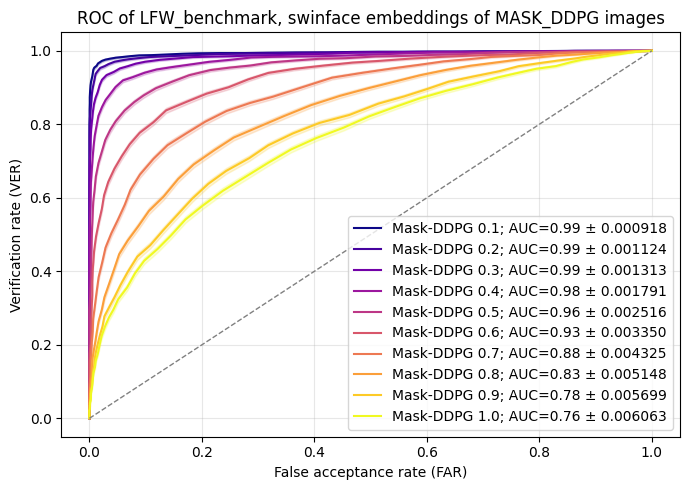

In [16]:
csv_files = [#pairs: path, label
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.1_MaskDDPG.csv','Mask-DDPG 0.1'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.2_MaskDDPG.csv','Mask-DDPG 0.2'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.3_MaskDDPG.csv','Mask-DDPG 0.3'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.4_MaskDDPG.csv','Mask-DDPG 0.4'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.5_MaskDDPG.csv','Mask-DDPG 0.5'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.6_MaskDDPG.csv','Mask-DDPG 0.6'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.7_MaskDDPG.csv','Mask-DDPG 0.7'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.8_MaskDDPG.csv','Mask-DDPG 0.8'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_0.9_MaskDDPG.csv','Mask-DDPG 0.9'),
    ('verification_results/swinface_LFW_benchmark_MASK_DDPG_transface/swinface_LFW_benchmark_1.0_MaskDDPG.csv','Mask-DDPG 1.0'),
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, swinface embeddings of MASK_DDPG images', n_bootstrap=1000)

Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 73.50it/s]


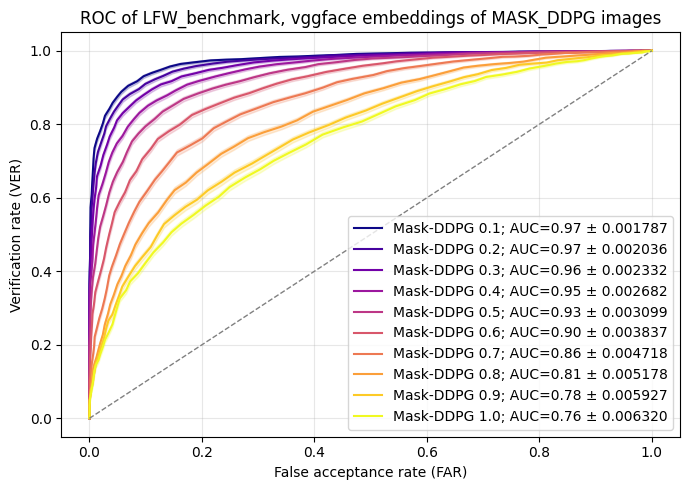

In [17]:
# Set the directory path for your CSV files
csv_files = [#pairs: path, label
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.1_MaskDDPG.csv','Mask-DDPG 0.1'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.2_MaskDDPG.csv','Mask-DDPG 0.2'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.3_MaskDDPG.csv','Mask-DDPG 0.3'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.4_MaskDDPG.csv','Mask-DDPG 0.4'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.5_MaskDDPG.csv','Mask-DDPG 0.5'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.6_MaskDDPG.csv','Mask-DDPG 0.6'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.7_MaskDDPG.csv','Mask-DDPG 0.7'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.8_MaskDDPG.csv','Mask-DDPG 0.8'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_0.9_MaskDDPG.csv','Mask-DDPG 0.9'),
    ('verification_results/vggface_LFW_benchmark_MASK_DDPG_transface/vggface_optimized_LFW_benchmark_1.0_MaskDDPG.csv','Mask-DDPG 1.0'),
]
plot_single_roc_with_uncertainty(csv_files,'ROC of LFW_benchmark, vggface embeddings of MASK_DDPG images', n_bootstrap=1000)

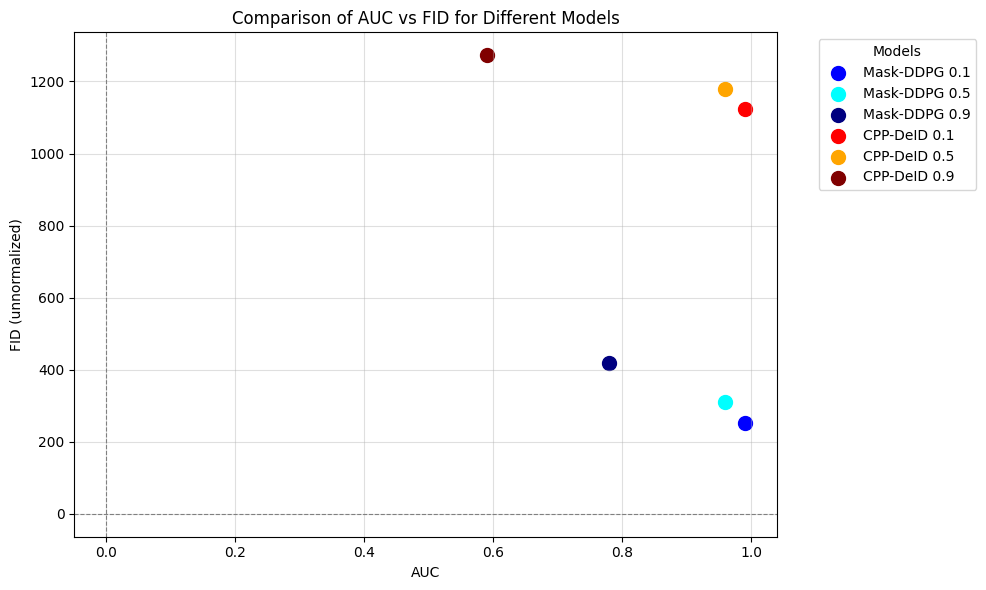

In [3]:
methods = [

    "Mask-DDPG 0.1", "Mask-DDPG 0.5", "Mask-DDPG 0.9",

    "CPP-DeID 0.1", "CPP-DeID 0.5", "CPP-DeID 0.9"

]

auc_values = [0.99, 0.96, 0.78, 0.99, 0.96, 0.59]

fid_values = [251.04, 310.35, 417.49, 1123.53, 1177.85, 1272.83]



# Plotting with grouped colors for Mask-DDPG and CPP-DeID

plt.figure(figsize=(10, 6))



# Define color palettes for the two groups

mask_ddpg_colors = ["blue", "cyan", "navy"]

cpp_deid_colors = ["red", "orange", "maroon"]



# Assign colors to each model

grouped_colors = {

    "Mask-DDPG 0.1": mask_ddpg_colors[0],

    "Mask-DDPG 0.5": mask_ddpg_colors[1],

    "Mask-DDPG 0.9": mask_ddpg_colors[2],

    "CPP-DeID 0.1": cpp_deid_colors[0],

    "CPP-DeID 0.5": cpp_deid_colors[1],

    "CPP-DeID 0.9": cpp_deid_colors[2]

}



for method, auc, fid in zip(methods, auc_values, fid_values):

    plt.scatter(auc, fid, label=method, color=grouped_colors[method], s=100)



# Customizing the plot

plt.xlabel("AUC")

plt.ylabel("FID (unnormalized)")

plt.title("Comparison of AUC vs FID for Different Models")

plt.axhline(0, color='gray', linewidth=0.8, linestyle="--")

plt.axvline(0, color='gray', linewidth=0.8, linestyle="--")

plt.legend(title="Models", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(alpha=0.4)

plt.tight_layout()



# Display the plot

plt.show()